In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [2]:
df = pd.read_csv("dailyActivity_merged.csv")

# EDA

In [3]:
df.sample(5)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
337,6391747486,4/4/2016,0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0,0,0,1440,1820
349,6775888955,4/7/2016,13987,10.03,10.03,0.0,2.87,3.34,3.82,0.0,46,114,250,739,3856
331,6290855005,4/8/2016,0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0,0,0,1440,2060
235,4319703577,4/4/2016,10067,6.76,6.76,0.0,0.36,1.42,4.97,0.0,5,39,313,578,2308
365,6962181067,4/12/2016,5893,3.90,3.90,0.0,2.88,0.56,0.46,0.0,43,9,48,146,917


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

In [5]:
df.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [6]:
df.isna().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [7]:
df["Id"].nunique()

35

In [8]:
Cols = ["Id","ActivityDate","TotalSteps" , "VeryActiveMinutes","FairlyActiveMinutes","LightlyActiveMinutes","SedentaryMinutes","Calories"]

In [9]:
df = df[Cols]

In [10]:
df.shape

(457, 8)

In [11]:
df.rename(columns={"ActivityDate" : "Date"} , inplace=True)

In [12]:
df.head()

,Id,Date,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,33,12,205,804,1819
1,1503960366,3/26/2016,17609,89,17,274,588,2154
2,1503960366,3/27/2016,12736,56,5,268,605,1944
3,1503960366,3/28/2016,13231,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,28,28,243,763,1886


In [13]:
df["TotalMinutes"] = df.VeryActiveMinutes + df.FairlyActiveMinutes + df.LightlyActiveMinutes + df.SedentaryMinutes

In [14]:
df["Hours"] = round(df.TotalMinutes / 60 , 0)

In [15]:
df.head()

,Id,Date,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,Hours
0,1503960366,3/25/2016,11004,33,12,205,804,1819,1054,18.0
1,1503960366,3/26/2016,17609,89,17,274,588,2154,968,16.0
2,1503960366,3/27/2016,12736,56,5,268,605,1944,934,16.0
3,1503960366,3/28/2016,13231,39,20,224,1080,1932,1363,23.0
4,1503960366,3/29/2016,12041,28,28,243,763,1886,1062,18.0


In [16]:
df['Date'] = pd.to_datetime(df.Date)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    457 non-null    int64         
 1   Date                  457 non-null    datetime64[ns]
 2   TotalSteps            457 non-null    int64         
 3   VeryActiveMinutes     457 non-null    int64         
 4   FairlyActiveMinutes   457 non-null    int64         
 5   LightlyActiveMinutes  457 non-null    int64         
 6   SedentaryMinutes      457 non-null    int64         
 7   Calories              457 non-null    int64         
 8   TotalMinutes          457 non-null    int64         
 9   Hours                 457 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(8)
memory usage: 35.8 KB


In [18]:
df["Dayofweek"] = df.Date.dt.day_name()

In [19]:
df.tail()

,Id,Date,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,Hours,Dayofweek
452,8877689391,2016-04-08,23014,70,29,359,982,4196,1440,24.0,Friday
453,8877689391,2016-04-09,16470,90,9,289,1052,3841,1440,24.0,Saturday
454,8877689391,2016-04-10,28497,128,46,211,1055,4526,1440,24.0,Sunday
455,8877689391,2016-04-11,10622,18,7,225,1190,2820,1440,24.0,Monday
456,8877689391,2016-04-12,2350,0,0,58,531,938,589,10.0,Tuesday


In [20]:
df.duplicated().sum()

0

# Statistical Indicators

In [21]:
df.describe().round() #Include = "all" if you'd like all datatypes in your description

,Id,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,Hours
count,4.570000e+02,457.0,457.0,457.0,457.0,457.0,457.0,457.0,457.0
mean,4.628595e+09,6547.0,17.0,13.0,170.0,995.0,2189.0,1195.0,20.0
std,2.293781e+09,5398.0,29.0,36.0,122.0,337.0,815.0,306.0,5.0
min,1.503960e+09,0.0,0.0,0.0,0.0,32.0,0.0,41.0,1.0
25%,2.347168e+09,1988.0,0.0,0.0,64.0,728.0,1776.0,985.0,16.0
50%,4.057193e+09,5986.0,0.0,1.0,181.0,1057.0,2062.0,1440.0,24.0
75%,6.391747e+09,10198.0,25.0,16.0,257.0,1285.0,2667.0,1440.0,24.0
max,8.877689e+09,28497.0,202.0,660.0,720.0,1440.0,4562.0,1440.0,24.0


# Data Visualizations

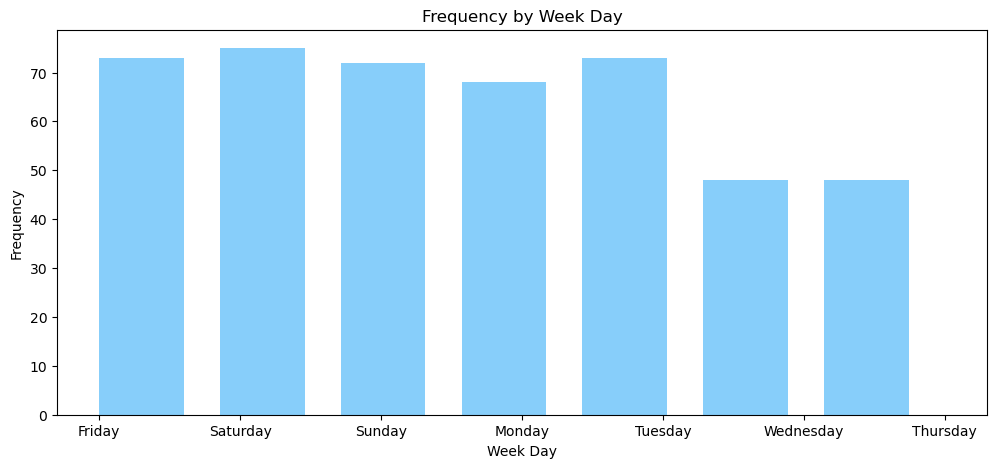

In [22]:
plt.figure( figsize = (12 , 5) )
plt.hist(x = df.Dayofweek , bins=7 , color="lightskyblue" , width = 0.6)

plt.xlabel("Week Day")
plt.ylabel("Frequency")
plt.title("Frequency by Week Day")

plt.show()

In [23]:
# throughout my initial analysis for our data, i have noticed that activities are reduced in days [wednesday & thursday]

In [24]:
df.corr()

,Id,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,Hours
Id,1.000000,0.138662,0.315967,0.001878,-0.073104,-0.027336,0.290868,-0.029175,-0.030675
TotalSteps,0.138662,1.000000,0.699699,0.238389,0.654418,-0.285258,0.581380,0.041449,0.042639
VeryActiveMinutes,0.315967,0.699699,1.000000,0.167764,0.199697,-0.177652,0.518905,-0.001548,0.000756
FairlyActiveMinutes,0.001878,0.238389,0.167764,1.000000,0.095449,-0.142598,0.334550,0.015226,0.014841
LightlyActiveMinutes,-0.073104,0.654418,0.199697,0.095449,1.000000,-0.393499,0.377249,-0.003854,-0.002054
SedentaryMinutes,-0.027336,-0.285258,-0.177652,-0.142598,-0.393499,1.000000,0.011824,0.909206,0.907674
Calories,0.290868,0.581380,0.518905,0.334550,0.377249,0.011824,1.000000,0.251934,0.254466
TotalMinutes,-0.029175,0.041449,-0.001548,0.015226,-0.003854,0.909206,0.251934,1.000000,0.999205
Hours,-0.030675,0.042639,0.000756,0.014841,-0.002054,0.907674,0.254466,0.999205,1.000000


In [25]:
df[["TotalSteps" , "Calories"]].corr()

,TotalSteps,Calories
TotalSteps,1.00000,0.58138
Calories,0.58138,1.00000


<AxesSubplot:>

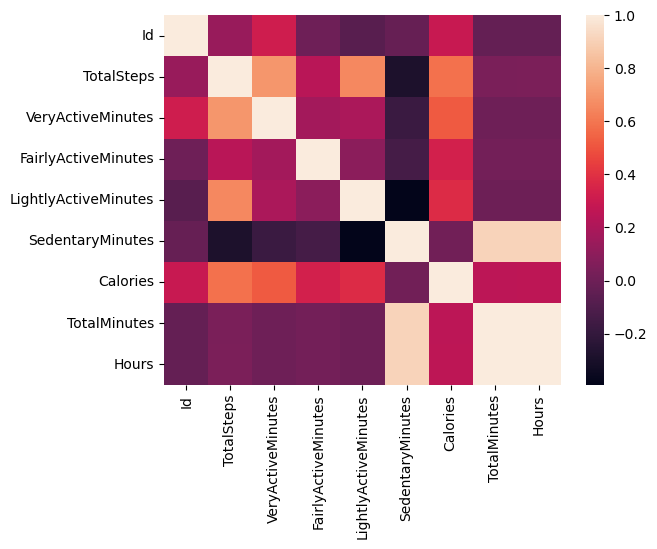

In [26]:
sns.heatmap(df.corr())

In [30]:
df[["TotalSteps" , "Calories"]].corr()

,TotalSteps,Calories
TotalSteps,1.00000,0.58138
Calories,0.58138,1.00000


<AxesSubplot:>

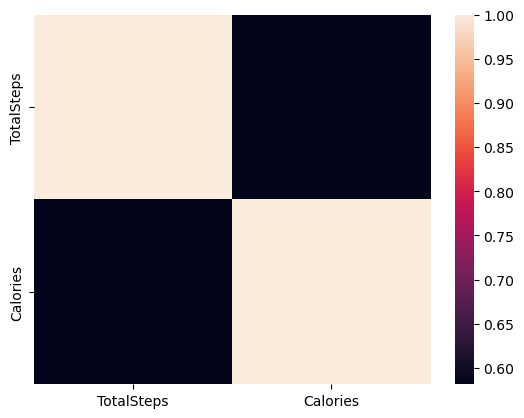

In [31]:
sns.heatmap(df[["TotalSteps" , "Calories"]].corr())

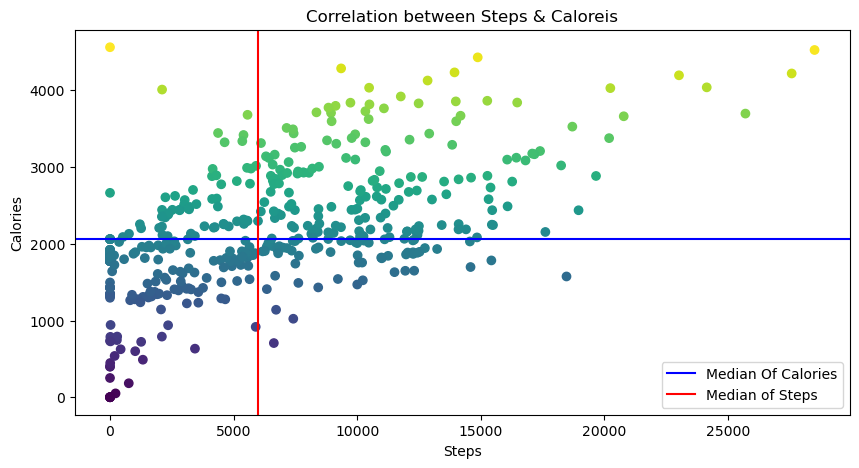

In [41]:
plt.figure(figsize=(10 , 5))
plt.scatter(x = df.TotalSteps , y = df.Calories , c = df.Calories )

plt.xlabel("Steps")
plt.ylabel("Calories")
plt.title("Correlation between Steps & Caloreis")

plt.axhline(df.Calories.median() , color = "blue" , label = "Median Of Calories")
plt.axvline(df.TotalSteps.median() , color = "red" , label = "Median of Steps")

plt.legend()
plt.show()

In [42]:
df.columns

Index(['Id', 'Date', 'TotalSteps', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'TotalMinutes',
       'Hours', 'Dayofweek'],
      dtype='object')

In [47]:
df[["Hours" , "Calories"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Hours,457.0,19.919037,5.123904,1.0,16.0,24.0,24.0,24.0
Calories,457.0,2189.452954,815.484523,0.0,1776.0,2062.0,2667.0,4562.0


In [46]:
df[["Hours" , "Calories"]].corr()

,Hours,Calories
Hours,1.000000,0.254466
Calories,0.254466,1.000000


<AxesSubplot:>

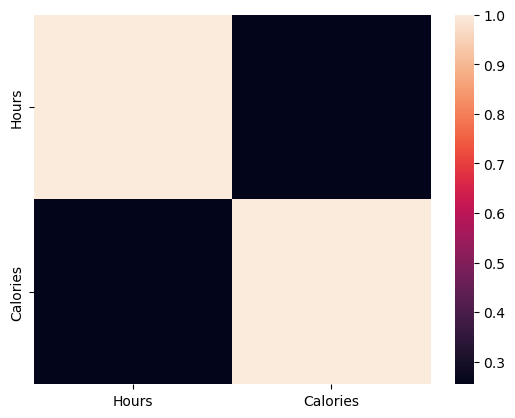

In [48]:
sns.heatmap(df[["Hours" , "Calories"]].corr())

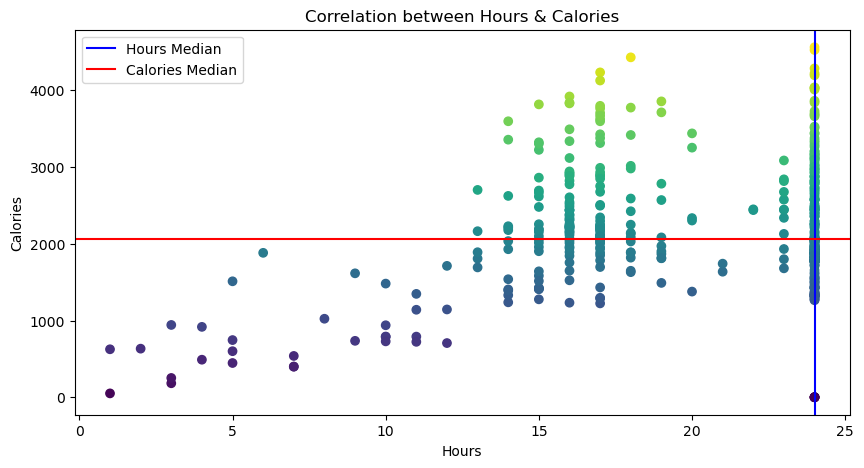

In [50]:
plt.figure(figsize=(10 , 5))
plt.scatter(x = df.Hours , y = df.Calories , c = df.Calories )

plt.xlabel("Hours")
plt.ylabel("Calories")
plt.title("Correlation between Hours & Calories")

Calories_Median = df.Calories.median()
Hours_Median = df.Hours.median()

plt.axvline(Hours_Median , color = "blue" , label = "Hours Median")
plt.axhline(Calories_Median , color = "red" , label = "Calories Median")

plt.legend()
plt.show()

In [51]:
df.head()

,Id,Date,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,Hours,Dayofweek
0,1503960366,2016-03-25,11004,33,12,205,804,1819,1054,18.0,Friday
1,1503960366,2016-03-26,17609,89,17,274,588,2154,968,16.0,Saturday
2,1503960366,2016-03-27,12736,56,5,268,605,1944,934,16.0,Sunday
3,1503960366,2016-03-28,13231,39,20,224,1080,1932,1363,23.0,Monday
4,1503960366,2016-03-29,12041,28,28,243,763,1886,1062,18.0,Tuesday


In [52]:

VeryActiveMinutes = df.VeryActiveMinutes.sum()
FairlyActiveMinutes = df.FairlyActiveMinutes.sum()
LightlyActiveMinutes = df.LightlyActiveMinutes.sum()
SedentaryMinutes = df.SedentaryMinutes.sum()

Minlist = [VeryActiveMinutes , FairlyActiveMinutes , LightlyActiveMinutes , SedentaryMinutes]
Labels = ['VeryActiveMinutes' , 'FairlyActiveMinutes' , 'LightlyActiveMinutes' , 'SedentaryMinutes']

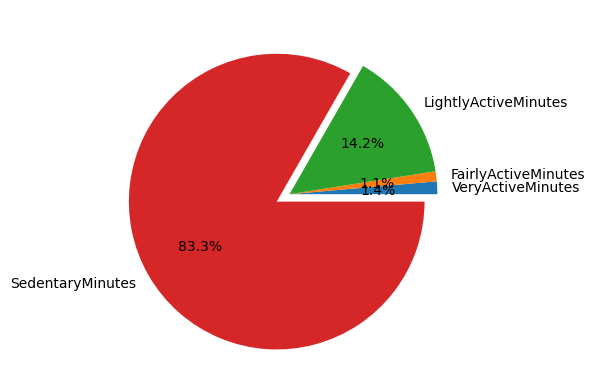

In [58]:
plt.pie(Minlist , labels = Labels , autopct="%1.1f%%" , explode = [0,0,0,0.1])
plt.show()